In [5]:
import pandas as pd 
import numpy as np
import time
import requests
import os
import sys
from datetime import datetime
import matplotlib.pyplot as plt
import joblib

feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
# feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)
    
from PROPS_EV.calculateEVS import *
from MODELS.model import *

today = datetime.now()
formatted_date = today.strftime("%m_%d_%y")
pd.set_option('display.max_columns', None)

In [11]:
pd.set_option('display.max_columns', None)

s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')

# bookmakers
bookmakers = pd.read_csv('../DATA/CSV_FILES/singleBets.csv')

data = pd.concat([s21, s22, s23, s24, s25])
data = data.drop(columns=['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.4'])
data.sort_values(by='GAME_DATE', inplace=True)
data

,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_SEASON_ID,TEAM_NAME,TEAM_GAME_DATE,TEAM_MATCHUP,TEAM_WL,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,VIDEO_AVAILABLE,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,STARTING,BLOWOUT_RISK,TEAM_IMPLIED_PTS_FAV,TEAM_IMPLIED_PTS_UND,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_EXPANDING_AVG,MIN_EXPANDING_AVG,FGA_EXPANDING_AVG,FTA_EXPANDING_AVG,FG3A_EXPANDING_AVG,FG_PCT_EXPANDING_AVG,FG3_PCT_EXPANDING_AVG,FT_PCT_EXPANDING_AVG,USG_PCT_EXPANDING_AVG,TS_PCT_EXPANDING_AVG,EFG_PCT_EXPANDING_AVG,POSS_EXPANDING_AVG,TCHS_EXPANDING_AVG,AST_EXPANDING_AVG,REB_EXPANDING_AVG,TOV_EXPANDING_AVG,PTS_ROLLING_AVG_3,MIN_ROLLING_AVG_3,FGA_ROLLING_AVG_3,FTA_ROLLING_AVG_3,FG3A_ROLLING_AVG_3,FG_PCT_ROLLING_AVG_3,FG3_PCT_ROLLING_AVG_3,FT_PCT_ROLLING_AVG_3,USG_PCT_ROLLING_AVG_3,TS_PCT_ROLLING_AVG_3,EFG_PCT_ROLLING_AVG_3,POSS_ROLLING_AVG_3,TCHS_ROLLING_AVG_3,AST_ROLLING_AVG_3,REB_ROLLING_AVG_3,TOV_ROLLING_AVG_3,PTS_ROLLING_AVG_5,MIN_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,POSS_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,AST_ROLLING_AVG_5,REB_ROLLING_AVG_5,TOV_ROLLING_AVG_5,PTS_ROLLING_AVG_7,MIN_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FTA_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FG_PCT_ROLLING_AVG_7,FG3_PCT_ROLLING_AVG_7,FT_PCT_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,POSS_ROLLING_AVG_7,TCHS_ROLLING_AVG_7,AST_ROLLING_AVG_7,REB_ROLLING_AVG_7,TOV_ROLLING_AVG_7,PTS_ROLLING_AVG_15,MIN_ROLLING_AVG_15,FGA_ROLLING_AVG_15,FTA_ROLLING_AVG_15,FG3A_ROLLING_AVG_15,FG_PCT_ROLLING_AVG_15,FG3_PCT_ROLLING_AVG_15,FT_PCT_ROLLING_AVG_15,USG_PCT_ROLLING_AVG_15,TS_PCT_ROLLING_AVG_15,EFG_PCT_ROLLING_AVG_15,POSS_ROLLING_AVG_15,TCHS_ROLLING_AVG_15,AST_ROLLING_AVG_15,REB_ROLLING_AVG_15,TOV_ROLLING_AVG_15,PTS_ROLLING_AVG_25,MIN_ROLLING_AVG_25,FGA_ROLLING_AVG_25,FTA_ROLLING_AVG_25,FG3A_ROLLING_AVG_25,FG_PCT_ROLLING_AVG_25,FG3_PCT_ROLLING_AVG_25,FT_PCT_ROLLING_AVG_25,USG_PCT_ROLLING_AVG_25,TS_PCT_ROLLING_AVG_25,EFG_PCT_ROLLING_AVG_25,POSS_ROLLING_AVG_25,TCHS_ROLLING_AVG_25,AST_ROLLING_AVG_25,REB_ROLLING_AVG_25,TOV_ROLLING_AVG_25,PTS_ROLLING_AVG_40,MIN_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,POSS_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,AST_ROLLING_AVG_40,REB_ROLLING_AVG_40,TOV_ROLLING_AVG_40,PTS_SEASON_AVG_TO_DATE,MIN_SEASON_AVG_TO_DATE,FGA_SEASON_AVG_TO_DATE,FTA_SEASON_AVG_TO_DATE,FG3A_SEASON_AVG_TO_DATE,FG_PCT_SEASON_AVG_TO_DATE,FG3_PCT_SEASON_AVG_TO_DATE,FT_PCT_SEASON_AVG_TO_DATE,USG_PCT_SEASON_AVG_TO_DATE,TS_PCT_SEASON_AVG_TO_DATE,EFG_PCT_SEASON_AVG_TO_DATE,POSS_SEASON_AVG_TO_DATE,TCHS_SEASON_AVG_TO_DATE,AST_SEASON_AVG_TO_DATE,REB_SEASON_AVG_TO_DATE,TOV_SEASON_AVG_TO_DATE,GAMES_VS_OPP,MATCHUP_AVG_MIN_LAST

In [7]:
# ================================================================================================
# COMPREHENSIVE EXPLORATORY DATA ANALYSIS (EDA) OF ENGINEERED FEATURES
# ================================================================================================

print("=== NBA POINTS PREDICTION - COMPREHENSIVE FEATURE ANALYSIS ===")
print(f"Dataset Shape: {data.shape}")
print(f"Date Range: {data['GAME_DATE'].min()} to {data['GAME_DATE'].max()}")
print(f"Number of Players: {data['PLAYER_NAME'].nunique()}")
print(f"Number of Games: {data['GAME_ID'].nunique()}")
print(f"Average Points per Game: {data['PTS'].mean():.2f}")
print(f"Points Standard Deviation: {data['PTS'].std():.2f}")

=== NBA POINTS PREDICTION - COMPREHENSIVE FEATURE ANALYSIS ===
Dataset Shape: (127695, 661)
Date Range: 2020-12-22 to 2025-04-13
Number of Players: 991
Number of Games: 6000
Average Points per Game: 10.63
Points Standard Deviation: 8.81


C:\Users\alexg\AppData\Local\Temp\ipykernel_16904\1875650707.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(position_data, labels=position_labels)


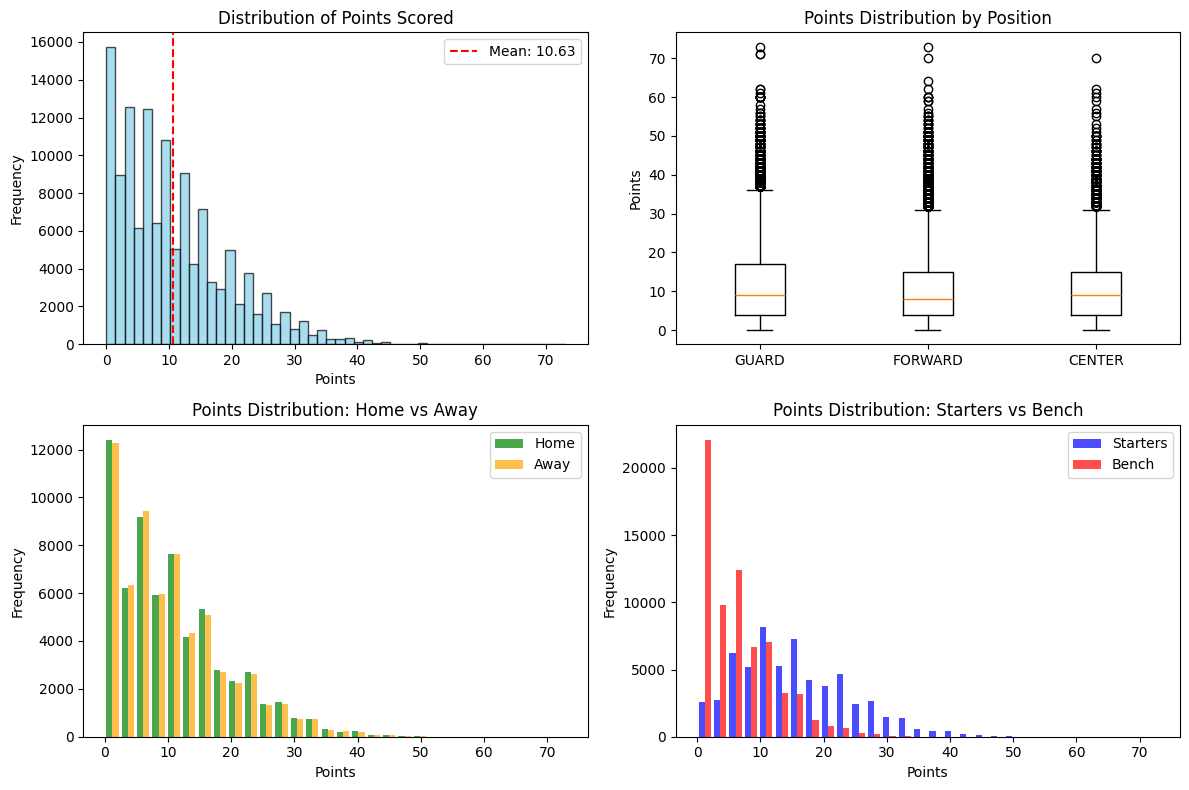


=== POINTS SCORING PATTERNS ===
Home games average: 10.69
Away games average: 10.57
Starters average: 15.59
Bench players average: 6.25
Guards average: 11.25
Forwards average: 10.24
Centers average: 10.35


In [9]:
# ================================================================================================
# 2. TARGET VARIABLE (PTS) DISTRIBUTION ANALYSIS
# ================================================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Points distribution
axes[0,0].hist(data['PTS'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution of Points Scored')
axes[0,0].set_xlabel('Points')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(data['PTS'].mean(), color='red', linestyle='--', label=f'Mean: {data["PTS"].mean():.2f}')
axes[0,0].legend()

# Box plot by position
position_data = []
position_labels = []
for pos in ['GUARD', 'FORWARD', 'CENTER']:
    if pos in data.columns:
        pos_pts = data[data[pos] == 1]['PTS']
        if len(pos_pts) > 0:
            position_data.append(pos_pts)
            position_labels.append(pos)

if position_data:
    axes[0,1].boxplot(position_data, labels=position_labels)
    axes[0,1].set_title('Points Distribution by Position')
    axes[0,1].set_ylabel('Points')

# Home vs Away scoring
if 'HOME_GAME' in data.columns:
    home_pts = data[data['HOME_GAME'] == 1]['PTS']
    away_pts = data[data['HOME_GAME'] == 0]['PTS']
    
    axes[1,0].hist([home_pts, away_pts], bins=30, alpha=0.7, 
                   label=['Home', 'Away'], color=['green', 'orange'])
    axes[1,0].set_title('Points Distribution: Home vs Away')
    axes[1,0].set_xlabel('Points')
    axes[1,0].set_ylabel('Frequency')
    axes[1,0].legend()

# Starting vs Bench scoring
if 'STARTING' in data.columns:
    starter_pts = data[data['STARTING'] == 1]['PTS']
    bench_pts = data[data['STARTING'] == 0]['PTS']
    
    axes[1,1].hist([starter_pts, bench_pts], bins=30, alpha=0.7,
                   label=['Starters', 'Bench'], color=['blue', 'red'])
    axes[1,1].set_title('Points Distribution: Starters vs Bench')
    axes[1,1].set_xlabel('Points')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].legend()

plt.tight_layout()
plt.show()

# Summary statistics by key categories
print("\n=== POINTS SCORING PATTERNS ===")
if 'HOME_GAME' in data.columns:
    print(f"Home games average: {data[data['HOME_GAME'] == 1]['PTS'].mean():.2f}")
    print(f"Away games average: {data[data['HOME_GAME'] == 0]['PTS'].mean():.2f}")

if 'STARTING' in data.columns:
    print(f"Starters average: {data[data['STARTING'] == 1]['PTS'].mean():.2f}")
    print(f"Bench players average: {data[data['STARTING'] == 0]['PTS'].mean():.2f}")

for pos in ['GUARD', 'FORWARD', 'CENTER']:
    if pos in data.columns:
        avg_pts = data[data[pos] == 1]['PTS'].mean()
        print(f"{pos.title()}s average: {avg_pts:.2f}")

In [22]:
lbjPoints = bookmakers[(bookmakers['NAME'] == 'LeBron James') & (bookmakers['CATEGORY'] == 'points') & (bookmakers['GAME_DATE'] <= '2024-12-01')]
lbjPoints

,NAME,CATEGORY,SIDE,BOOKMAKER,LINE,ODDS,GAME_DATE
268,LeBron James,points,under,hardrockbet,15.5,100.0,2024-10-23
269,LeBron James,points,under,fliff,15.5,-200.0,2024-10-23
270,LeBron James,points,under,espnbet,15.5,-140.0,2024-10-23
271,LeBron James,points,under,sporttrade,21.5,-733.0,2024-10-23
282,LeBron James,points,over,hardrockbet,15.5,-130.0,2024-10-23
...,...,...,...,...,...,...,...
53223,LeBron James,points,under,sporttrade,18.5,-167.0,2024-11-30
53224,LeBron James,points,under,fourwinds,22.5,-115.0,2024-11-30
53225,LeBron James,points,under,betrivers,22.5,-115.0,2024-11-30
55621,LeBron James,points,under,caesars,27.5,-166.0,2024-12-01
